In [1]:
from gsfit_rs.analytic_grad_shafranov.guazzotto_freidberg import Configuration, GuazzottoFreidberg
from gsfit_rs.imas import equilibrium_paths as ep
import matplotlib.pyplot as plt

In [2]:
# %matplotlib inline
# %matplotlib widget

In [3]:
"""Example 14 - Guazzotto-Freidberg analytic Grad-Shafranov equilibrium.

Builds the up-down symmetric *double-null* spherical tokamak of
Guazzotto & Freidberg, J. Plasma Phys. 87 (2021) 905870303 (Figure 7 / Table 2:
eps = 0.75, kappa_X = 2.4, delta_X = 0.8, nu = 1.04; reference eigenvalue
alpha ~ 1.90 from Table 4), then fits the PF-coil currents on the (R, Z) grid
boundary that reproduce its vacuum field - a self-consistent, free-boundary test
case that GSFit can be asked to reconstruct.
"""

import math

# --- Dimensionless shape / profile (GF Fig. 7 double-null spherical tokamak) ---
eps = 0.75  # inverse aspect ratio a / r_geo (R0/a = 1.33; strongly spherical)
kappa_x = 2.4  # X-point elongation
delta_x = 0.8  # X-point triangularity
nu = 1.04  # profile parameter (~ poloidal beta)

# --- Dimensional inputs (illustrative, MAST-U-like; set scale only, not shape) ---
r_geo = 0.85  # geometric major radius [metre]
b_vacuum = 0.5  # vacuum toroidal field at r_geo [tesla]
p_axis = 2.0e4  # pressure on the magnetic axis [pascal]

# --- (R, Z) grid; PF coils are placed on its boundary ---
# Memory in `get_coils` grows as (grid points) x (plasma cells), i.e. as d_grid_gf ** -4: 129 x 129 (12.3 x 27 mm) peaked at 5.1 GiB, and 10 mm needs ~50 GiB
d_grid_gf = 0.014  # grid spacing in both R and Z [metre]; finer grid -> tight PF-coil boundary match
a_minor = eps * r_geo  # minor radius [metre]
z_half = kappa_x * a_minor  # plasma half-height, X-points at ~ +/- z_half [metre]
r_min = max(0.02, r_geo - a_minor - 0.15)  # keep r_min > 0 [metre]
# r_max and z_max are pushed out to the next whole number of grid spacings, so that d_r = d_z = d_grid_gf exactly.
# The small tolerance stops a quotient such as 172.99999999999997 from being rounded up to an extra interval.
n_r = math.ceil((r_geo + a_minor + 0.15 - r_min) / d_grid_gf - 1.0e-9) + 1
n_z_half_interval = math.ceil((z_half + 0.20) / d_grid_gf - 1.0e-9)
n_z = 2 * n_z_half_interval + 1
r_max = r_min + (n_r - 1) * d_grid_gf  # [metre]
z_max = n_z_half_interval * d_grid_gf  # [metre]
z_min = -z_max  # [metre]

# --- Numerical control ---
n_radial_expansion = 150  # C_n / S_n series length; large eps (spherical) needs many terms

# 1. Boundary topology + its shape (double-null carries kappa_x, delta_x)
configuration = Configuration.DoubleNull(kappa_x=kappa_x, delta_x=delta_x)

# 2. Construct the analytic equilibrium
gf = GuazzottoFreidberg(
    configuration,
    eps=eps,
    nu=nu,
    r_geo=r_geo,
    bt_vac_at_r_geo=b_vacuum,
    p_axis=p_axis,
    n_r=n_r,
    n_z=n_z,
    r_min=r_min,
    r_max=r_max,
    z_min=z_min,
    z_max=z_max,
    n_radial_expansion=n_radial_expansion,
)
print(f"GF double-null spherical tokamak: eps={eps}, kappa_x={kappa_x}, delta_x={delta_x}, nu={nu}")
print(f"grid: R in [{r_min:.4f}, {r_max:.4f}] m, Z in [{z_min:.4f}, {z_max:.4f}] m, {n_r}x{n_z}, d_r = d_z = {d_grid_gf * 1.0e3:.1f} mm")

# 3. Solve the eigenvalue alpha and the normalised flux psi(R, Z)
gf.solve()

GF double-null spherical tokamak: eps=0.75, kappa_x=2.4, delta_x=0.8, nu=1.04
grid: R in [0.0625, 1.6445] m, Z in [-1.7360, 1.7360] m, 114x249, d_r = d_z = 14.0 mm


alpha = 1.9021;  beta_0 = 0.2011;  bt_diamagnetic_shift = -3.021 mT;  psi_0 = 0.3935 Wb


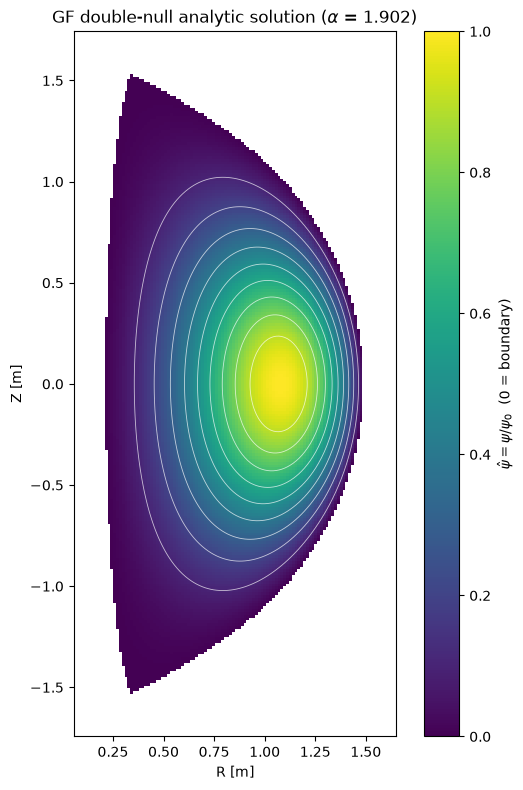

In [4]:
import numpy as np

# --- The analytic solution on the (R, Z) grid ---
# The equilibrium IDS is only filled once the PF coils are fitted (next cell); until then the
# analytic flux and the plasma mask are what `solve()` provides.
r = np.linspace(gf.r_min, gf.r_max, gf.n_r)
z = np.linspace(gf.z_min, gf.z_max, gf.n_z)
mask = gf.mask  # 1 inside the analytic plasma, 0 elsewhere
# GF's normalised flux: 1 at (x, y) = (0, 0) and 0 on the boundary. NaN outside the plasma, where the
# truncated series is unphysical
psi_hat = np.where(mask > 0, gf.psi_analytic / gf.psi_0, np.nan)
print(f"alpha = {gf.alpha:.4f};  beta_0 = {gf.beta_0:.4f};  bt_diamagnetic_shift = {gf.bt_diamagnetic_shift * 1e3:.3f} mT;  psi_0 = {gf.psi_0:.4f} Wb")

fig, ax = plt.subplots(figsize=(6, 8))
# A pixel plot rather than a filled contour: `contourf` leaves a jagged edge where the plasma meets the NaN outside it.
# `shading="nearest"` centres each pixel on its grid point.
fill = ax.pcolormesh(r, z, psi_hat, vmin=0.0, vmax=1.0, cmap="viridis", shading="nearest")
fig.colorbar(fill, ax=ax, label="$\\hat{\\psi} = \\psi / \\psi_0$  (0 = boundary)")
ax.contour(r, z, psi_hat, levels=np.linspace(0.1, 0.9, 9), colors="white", linewidths=0.6, alpha=0.7)
ax.set_aspect("equal")
ax.set_xlabel("R [m]")
ax.set_ylabel("Z [m]")
ax.set_title(f"GF double-null analytic solution ($\\alpha$ = {gf.alpha:.3f})")
fig.tight_layout()
plt.show()

PF coils (unknowns)                     : 722
plasma grid points constraining the fit : 14269
least squares: 14269 constraints vs 722 unknowns -> OVER-determined
chi^2 of the vacuum flux fit            : 4.735e-10


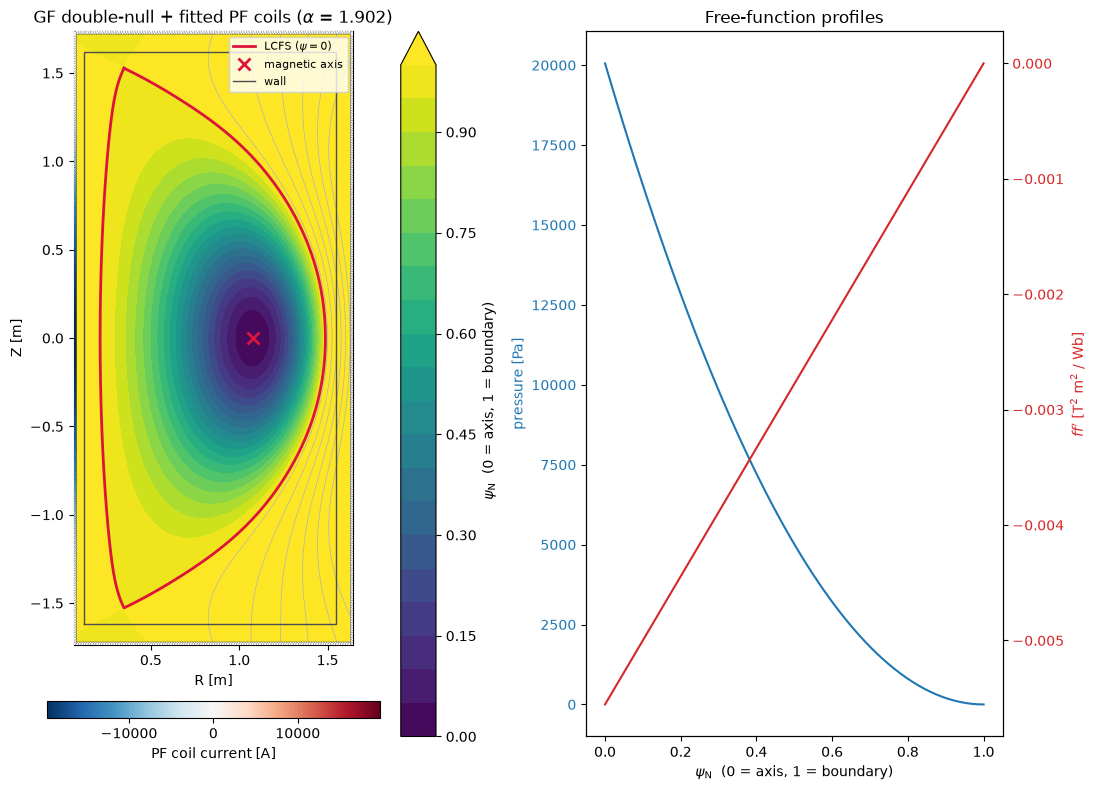

In [5]:
# --- Fit PF coils to reproduce the equilibrium, print the fit determinacy, then plot the free-boundary equilibrium ---
from gsfit_rs import Wall

# Whole-domain control: constrain the total flux at every analytic plasma grid point,
# so the grid points inside the plasma are the least-squares constraints.
mesh_r, mesh_z = np.meshgrid(r, z)  # (n_z, n_r)
control_points = np.column_stack([mesh_r[mask > 0], mesh_z[mask > 0]])

# Wall: a rectangle enclosing the (diverted) plasma with a margin. The post-processor traces the scrape-off
# layer legs up to it, and GSFit's reconstruction below uses it as the limiter and vacuum vessel.
# `unit(0)` is the vacuum vessel contour; it is the only limiter unit, so it also supplies every candidate limit point.
lim_r_lo, lim_r_hi = 0.12, 1.55
lim_z_lo, lim_z_hi = -1.62, 1.62
n_side = 60
edge_r = np.linspace(lim_r_lo, lim_r_hi, n_side)
edge_z = np.linspace(lim_z_lo, lim_z_hi, n_side)
limiter_r = np.concatenate([edge_r, np.full(n_side, lim_r_hi), edge_r[::-1], np.full(n_side, lim_r_lo)])
limiter_z = np.concatenate([np.full(n_side, lim_z_lo), edge_z, np.full(n_side, lim_z_hi), edge_z[::-1]])
wall = Wall()
wall.add_limiter_unit(name="vacuum_vessel", r=limiter_r, z=limiter_z)

# Fits the coils, stores the free-boundary equilibrium (plasma + coils) in the IDS, and post-processes it
gf_coils = gf.get_coils(coil_regularisation_weight=1.0e-6, control_points=control_points, wall=wall)

# --- Read the free-boundary equilibrium back out of the IDS ---
# The flux is the total (plasma + coils), so it is valid in the vacuum as well. The magnetic axis, the
# boundary flux (0) and the X-points are the analytic ones.
gf_equilibrium_ids = gf.equilibrium_ids
psi_total = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)
psi_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)
psi_boundary = gf_equilibrium_ids.get(ep.time_slice[0].boundary.psi)
# Not masked, unlike `profiles_2d/psi_norm`, so it carries on past 1 into the vacuum
psi_norm_total = (psi_total - psi_axis) / (psi_boundary - psi_axis)
boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)

# One single-filament coil per GF boundary node
gf_coil_names = gf_coils.keys(["pf"])
coil_r = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "r"])[0] for coil_name in gf_coil_names])
coil_z = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "z"])[0] for coil_name in gf_coil_names])
coil_current = np.array([gf_coils.get_array1(["pf", coil_name, "i", "experimental", "value"])[0] for coil_name in gf_coil_names])

# --- Determinacy of the least-squares fit (constraints vs unknowns) ---
n_coil = coil_current.size
n_constraint = control_points.shape[0]
status = "OVER-determined" if n_constraint >= n_coil else "UNDER-determined"
print(f"PF coils (unknowns)                     : {n_coil}")
print(f"plasma grid points constraining the fit : {n_constraint}")
print(f"least squares: {n_constraint} constraints vs {n_coil} unknowns -> {status}")

# --- Quality of the fit: chi^2 of the vacuum flux at the plasma grid points (the control points) ---
# The coils are fitted so that their flux matches the GF vacuum flux, psi_vac^GF = psi^GF - psi_plasma, where psi^GF is the
# analytic flux and psi_plasma is the flux of the GF plasma current. The coil flux is psi_vac^PF.
# chi^2 = 1 / N_plas * sum_k [(psi_vac^GF(R_k, Z_k) - psi_vac^PF(R_k, Z_k)) / (psi_GF,axis - psi_GF,boundary)] ** 2
psi_coils = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi_coils)  # [weber]
psi_plasma = psi_total - psi_coils  # [weber]
psi_vacuum_gf = gf.psi_analytic[mask > 0] - psi_plasma[mask > 0]  # [weber]
psi_vacuum_pf = psi_coils[mask > 0]  # [weber]
chi_sq = np.mean(((psi_vacuum_gf - psi_vacuum_pf) / (psi_axis - psi_boundary)) ** 2)  # [dimensionless]
print(f"chi^2 of the vacuum flux fit            : {chi_sq:.3e}")

fig, (ax_flux, ax_profile) = plt.subplots(1, 2, figsize=(11, 8))

# --- Panel 1: total flux surfaces + fitted PF coils ---
fill = ax_flux.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="viridis", extend="max")
fig.colorbar(fill, ax=ax_flux, label="$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
# A few vacuum flux surfaces (psi_N > 1) show the coil-shaped field outside the plasma.
ax_flux.contour(r, z, psi_norm_total, levels=np.linspace(1.05, 1.6, 6), colors="0.7", linewidths=0.5)
ax_flux.plot(boundary_r, boundary_z, color="crimson", lw=2.0, label="LCFS ($\\psi = 0$)")
ax_flux.plot(mag_r, mag_z, "x", color="crimson", ms=9, mew=2, label="magnetic axis")
current_abs_max = np.abs(coil_current).max()
scatter = ax_flux.scatter(
    coil_r,
    coil_z,
    c=coil_current,
    cmap="RdBu_r",
    vmin=-current_abs_max,
    vmax=current_abs_max,
    s=18,
    edgecolors="k",
    linewidths=0.2,
    zorder=5,
)
fig.colorbar(scatter, ax=ax_flux, location="bottom", label="PF coil current [A]", pad=0.08, fraction=0.05)
ax_flux.plot(limiter_r, limiter_z, color="0.3", lw=1.0, label="wall")
ax_flux.set_aspect("equal")
ax_flux.set_xlabel("R [m]")
ax_flux.set_ylabel("Z [m]")
ax_flux.set_title(f"GF double-null + fitted PF coils ($\\alpha$ = {gf.alpha:.3f})")
ax_flux.legend(loc="upper right", fontsize=8)

# --- Panel 2: pressure and ff' vs psi_N ---
profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
profile_pressure = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.pressure)
profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)
ax_profile.plot(profile_psi_n, profile_pressure, color="tab:blue")
ax_profile.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_profile.set_ylabel("pressure [Pa]", color="tab:blue")
ax_profile.tick_params(axis="y", labelcolor="tab:blue")
ax_ff_prime = ax_profile.twinx()
ax_ff_prime.plot(profile_psi_n, profile_ff_prime, color="tab:red")
ax_ff_prime.set_ylabel("$ff'$ [T$^2$ m$^2$ / Wb]", color="tab:red")
ax_ff_prime.tick_params(axis="y", labelcolor="tab:red")
ax_profile.set_title("Free-function profiles")

fig.tight_layout()
plt.show()

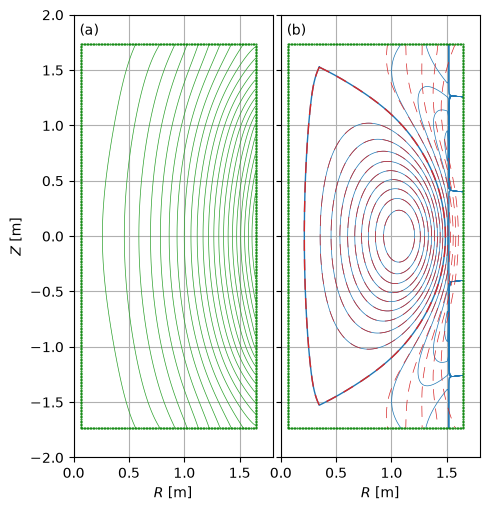

In [6]:
# --- (a) The vacuum field of the fitted PF coils; (b) the analytic solution against the analytic + PF-coil (free-boundary) solution ---
# Same flux between neighbouring contours in both panels; in (b) expect agreement inside the plasma, disagreement outside.

# Unmasked analytic flux on the whole grid: the truncated series is invalid - and diverges far
# outside - but it is kept unmasked so it can be plotted anyway for comparison.
psi_analytic = gf.psi_analytic

psi_mag_axis = gf.equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)
psi_b = gf.equilibrium_ids.get(ep.time_slice[0].boundary.psi)

# Plasma boundary from the IDS: traced by the post-processor's marching squares on the total flux
# (sub-grid resolution, unlike a grid contour)
gf_boundary_r = gf.equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
gf_boundary_z = gf.equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)

# (b): flux surfaces evenly spaced in psi_N, from the axis out into the vacuum. psi_N = 1 is left out, as the
# plasma boundary is drawn instead. The levels stop at psi_N = 1.5 so the far-field divergence of the series
# cannot reach them: matplotlib draws no lines where it has run off to +/-1e15, leaving a clean comparison.
psi_n_step = 0.1
psi_n_levels = psi_n_step * np.arange(1, 16)
psi_n_levels = psi_n_levels[~np.isclose(psi_n_levels, 1.0)]
psi_n_analytic = (psi_analytic - psi_mag_axis) / (psi_b - psi_mag_axis)
psi_n_total = (psi_total - psi_mag_axis) / (psi_b - psi_mag_axis)

# (a): the coil flux is negative over the whole grid, mostly beyond the levels in (b), so the levels are carried on
# downwards at the same spacing: the flux between neighbouring contours is the same in both panels
level_spacing = psi_n_step * (psi_mag_axis - psi_b)  # [weber]
levels_vacuum = np.arange(psi_mag_axis, psi_coils.min(), -level_spacing)[::-1]

# Long dashes with long gaps for the analytic + PF-coil lines: 8 point dashes, 6 point gaps. matplotlib scales a dash
# pattern by the line width, so each pattern is divided by its line's width to give the same dashes on both
long_dash_contour = (0, (16.0, 12.0))  # for linewidth 0.5
long_dash_boundary = (0, (8.0, 6.0))  # for linewidth 1.0

fig, (ax_vacuum, ax_total) = plt.subplots(1, 2, figsize=(5.0, 5.5), sharey=True)

# (a) Vacuum field of the fitted PF coils: solid green
ax_vacuum.contour(r, z, psi_coils, levels=levels_vacuum, colors="tab:green", linestyles="solid", linewidths=0.5)

# (b) Analytic solution: solid blue
ax_total.contour(r, z, psi_n_analytic, levels=psi_n_levels, colors="tab:blue", linestyles="solid", linewidths=0.5)
# Analytic + PF coils: long-dashed red, at the SAME levels
ax_total.contour(r, z, psi_n_total, levels=psi_n_levels, colors="tab:red", linestyles=[long_dash_contour], linewidths=0.5)
# Analytic plasma boundary drawn thicker: psi_analytic = 0, the edge of the analytic plasma mask. Where the plasma meets
# the scrape-off layer the flux is left as it is, so the contour sits on psi = 0. Everywhere else outside the mask is
# made negative - the private flux regions past the X-points (psi > 0 there too, but outside GF's model box) and the
# series' far-field divergence - so the contour closes at the X-points and draws nothing else.
psi_analytic_plasma = np.where(gf.mask > 0, psi_analytic, -np.abs(psi_analytic))
# ax_total.contour(r, z, psi_analytic_plasma, levels=[0.0], colors="blue", linestyles="solid", linewidths=1.0)
# Analytic + PF coils plasma boundary drawn thicker
ax_total.plot(gf_boundary_r, gf_boundary_z, color="tab:blue", linestyle="-", linewidth=1.0)
ax_total.plot(gf_boundary_r, gf_boundary_z, color="tab:red", linestyle=long_dash_boundary, linewidth=1.0)

for ax, panel_label in [(ax_vacuum, "(a)"), (ax_total, "(b)")]:
    ax.plot(
        coil_r,
        coil_z,
        color="green",
        linestyle="none",
        marker="o",
        markersize=0.5,
    )

    ax.set_aspect("equal")
    ax.set_xlabel("$R$ [m]")
    ax.set_xlim(0.0, 1.8)
    ax.set_ylim(-2.0, 2.0)
    ax.text(0.03, 0.98, panel_label, transform=ax.transAxes, ha="left", va="top")
ax_vacuum.set_ylabel("$Z$ [m]")
fig.tight_layout()
# A small gap between the panels: `wspace` is a fraction of the panel width. The equal aspect shrinks each axes
# inside its slot, so pin them to the inner edges or the gap would be wider
fig.subplots_adjust(wspace=0.04)
ax_vacuum.set_anchor("E")
ax_total.set_anchor("W")

ax_vacuum.grid(True)
ax_total.grid(True)

fig.savefig("gf_analytic_vs_gf_plus_pf_coils.pdf")

Synthetic sensors on the GF equilibrium: 40 flux loops, 42 poloidal BP probes


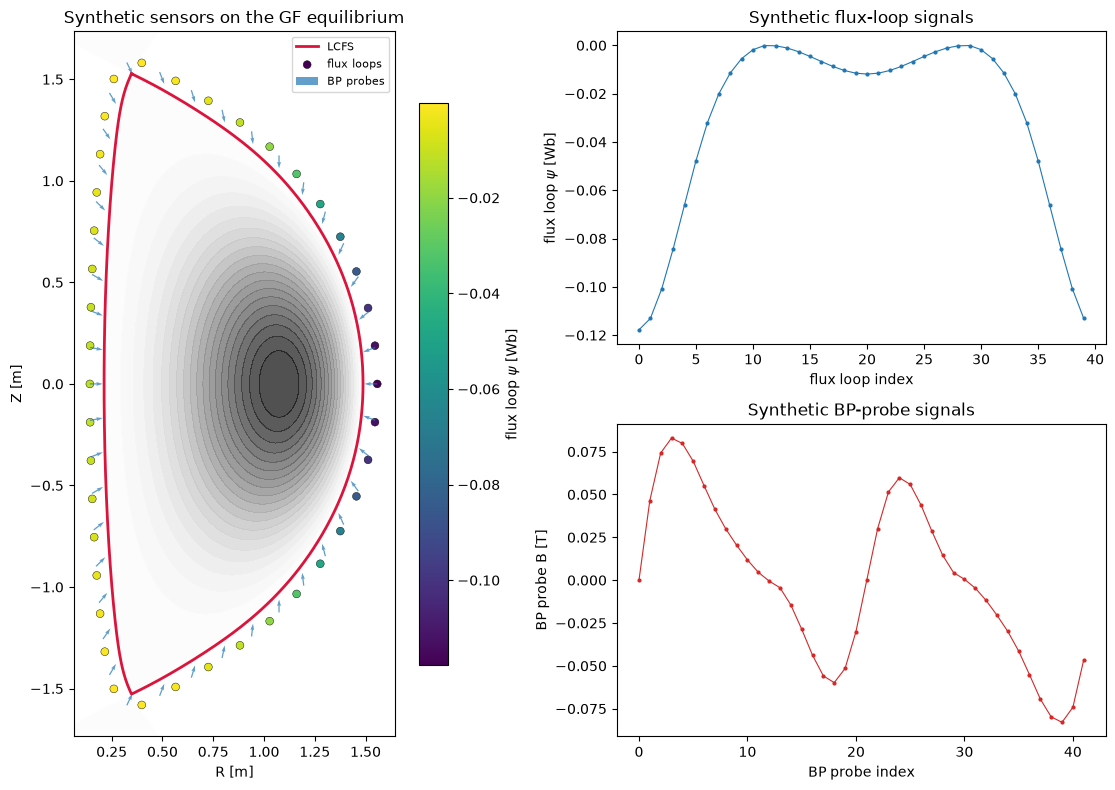

In [7]:
# --- Synthetic magnetic diagnostics from the GF equilibrium ---
# Build a custom sensor set 7 cm outside the plasma: 40 flux loops and 42 BP probes, each set equally spaced by arc length around an outward-offset copy of the free-boundary LCFS.
# Each set is up/down symmetric, with one sensor on the midplane on the high field side and one on the low field side.
# The BP probes are oriented to point at the magnetic axis. Requires get_coils() above.
import numpy.typing as npt
from gsfit_rs import BpProbes, FluxLoops

sensor_standoff = 0.07  # perpendicular gap between the plasma boundary and the sensors [metre]
n_flux_loop = 40  # must be even, see `sensor_ring`
n_bp_probe = 42  # must be even, see `sensor_ring`

# --- Free-boundary LCFS + magnetic axis from the equilibrium IDS ---
lcfs_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
lcfs_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)
mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)
mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)


def sensor_ring(
    boundary_r: npt.NDArray[np.float64],
    boundary_z: npt.NDArray[np.float64],
    axis_r: float,
    axis_z: float,
    standoff: float,
    n_sensor: int,
) -> tuple[npt.NDArray[np.float64], npt.NDArray[np.float64]]:
    """
    Place sensors, equally spaced by arc length and up/down symmetric about the midplane, on a curve `standoff` outside a closed boundary.

    The curve is the boundary offset along its outward normal (away from the magnetic axis).
    Its upper half, from the low field side midplane to the high field side midplane, is sampled at n_sensor / 2 + 1 points equally spaced by arc length,
    so there is a sensor on the midplane on both the low and the high field side.
    The lower half's sensors are the mirror images of the upper half's in Z = axis_z.
    This makes the set exactly up/down symmetric, although the traced boundary is only symmetric to within its tracing accuracy.
    The sensors are ordered anticlockwise in (R, Z), starting on the low field side midplane.

    :param boundary_r: Closed boundary radial positions [metre]
    :param boundary_z: Closed boundary vertical positions [metre]
    :param axis_r: Magnetic axis radial position [metre]
    :param axis_z: Magnetic axis vertical position, which defines the midplane [metre]
    :param standoff: Perpendicular gap between the boundary and the sensors [metre]
    :param n_sensor: Number of sensors; must be even, as the two midplane sensors are unpaired and every other sensor has a mirror image
    :return: Sensor radial positions [metre] and vertical positions [metre], each shape (n_sensor,)
    """
    if n_sensor % 2 != 0:
        raise ValueError(f"n_sensor = {n_sensor} must be even, for an up/down symmetric set with a sensor on both midplanes")

    boundary_r = np.asarray(boundary_r, dtype=float)
    boundary_z = np.asarray(boundary_z, dtype=float)
    # Drop a duplicate closing vertex so the loop is not double-counted.
    if np.hypot(boundary_r[0] - boundary_r[-1], boundary_z[0] - boundary_z[-1]) < 1.0e-9:
        boundary_r = boundary_r[:-1]
        boundary_z = boundary_z[:-1]

    # Outward normal at each vertex: rotate the wrapped central-difference tangent by 90 degrees,
    # then flip it to point away from the magnetic axis.
    tangent_r = np.roll(boundary_r, -1) - np.roll(boundary_r, 1)
    tangent_z = np.roll(boundary_z, -1) - np.roll(boundary_z, 1)
    normal_r = tangent_z
    normal_z = -tangent_r
    normal_length = np.maximum(np.hypot(normal_r, normal_z), 1.0e-12)
    normal_r /= normal_length
    normal_z /= normal_length
    pointing_inward = (boundary_r - axis_r) * normal_r + (boundary_z - axis_z) * normal_z < 0.0
    normal_r[pointing_inward] *= -1.0
    normal_z[pointing_inward] *= -1.0

    offset_r = boundary_r + standoff * normal_r
    offset_z = boundary_z + standoff * normal_z

    # Orient the offset curve anticlockwise in (R, Z), from the sign of its shoelace area, so it rises through the low field side midplane
    signed_area = 0.5 * np.sum(offset_r * np.roll(offset_z, -1) - np.roll(offset_r, -1) * offset_z)  # [metre^2]
    if signed_area < 0.0:
        offset_r = offset_r[::-1]
        offset_z = offset_z[::-1]

    # Find the segments on which the curve crosses the midplane: upwards on the low field side and downwards on the high field side.
    # A vertex exactly on the midplane belongs to only one crossing segment, as the comparisons are strict on one side.
    n_vertex = offset_r.size
    i_vertex_low_field_side_list = []
    i_vertex_high_field_side_list = []
    for i_vertex in range(n_vertex):
        i_vertex_next = (i_vertex + 1) % n_vertex
        if offset_z[i_vertex] < axis_z <= offset_z[i_vertex_next] and offset_r[i_vertex] > axis_r:
            i_vertex_low_field_side_list.append(i_vertex)
        if offset_z[i_vertex] >= axis_z > offset_z[i_vertex_next] and offset_r[i_vertex] < axis_r:
            i_vertex_high_field_side_list.append(i_vertex)
    if len(i_vertex_low_field_side_list) != 1 or len(i_vertex_high_field_side_list) != 1:
        raise ValueError(
            f"the offset curve must cross the midplane once on each side; found {len(i_vertex_low_field_side_list)} low field side "
            f"and {len(i_vertex_high_field_side_list)} high field side crossings"
        )
    i_vertex_low_field_side = i_vertex_low_field_side_list[0]
    i_vertex_high_field_side = i_vertex_high_field_side_list[0]

    # The upper half of the curve: the low field side midplane crossing, the vertices above the midplane, and the high field side midplane crossing
    n_upper_vertex = (i_vertex_high_field_side - i_vertex_low_field_side) % n_vertex
    upper_r = np.full(n_upper_vertex + 2, np.nan)  # [metre]
    upper_z = np.full(n_upper_vertex + 2, np.nan)  # [metre]
    i_vertex = i_vertex_low_field_side
    i_vertex_next = (i_vertex + 1) % n_vertex
    fraction = (axis_z - offset_z[i_vertex]) / (offset_z[i_vertex_next] - offset_z[i_vertex])  # [dimensionless]
    upper_r[0] = offset_r[i_vertex] + fraction * (offset_r[i_vertex_next] - offset_r[i_vertex])
    upper_z[0] = axis_z
    for i_upper_vertex in range(n_upper_vertex):
        i_vertex = (i_vertex_low_field_side + 1 + i_upper_vertex) % n_vertex
        upper_r[i_upper_vertex + 1] = offset_r[i_vertex]
        upper_z[i_upper_vertex + 1] = offset_z[i_vertex]
    i_vertex = i_vertex_high_field_side
    i_vertex_next = (i_vertex + 1) % n_vertex
    fraction = (axis_z - offset_z[i_vertex]) / (offset_z[i_vertex_next] - offset_z[i_vertex])  # [dimensionless]
    upper_r[-1] = offset_r[i_vertex] + fraction * (offset_r[i_vertex_next] - offset_r[i_vertex])
    upper_z[-1] = axis_z

    # Sample the upper half at equal arc length, including both of its ends, which are the midplane sensors
    n_sensor_half = n_sensor // 2
    arc_length = np.concatenate([[0.0], np.cumsum(np.hypot(np.diff(upper_r), np.diff(upper_z)))])  # [metre]
    sample_arc_length = np.linspace(0.0, arc_length[-1], n_sensor_half + 1)  # [metre]
    upper_sample_r = np.interp(sample_arc_length, arc_length, upper_r)  # [metre]
    upper_sample_z = np.interp(sample_arc_length, arc_length, upper_z)  # [metre]

    sensor_r = np.full(n_sensor, np.nan)  # [metre]
    sensor_z = np.full(n_sensor, np.nan)  # [metre]
    # Upper half, from the low field side midplane over the top to the high field side midplane
    for i_sample in range(n_sensor_half + 1):
        sensor_r[i_sample] = upper_sample_r[i_sample]
        sensor_z[i_sample] = upper_sample_z[i_sample]
    # Lower half, continuing anticlockwise: the mirror images of the upper half's sensors that are not on the midplane
    for i_sample in range(1, n_sensor_half):
        sensor_r[n_sensor - i_sample] = upper_sample_r[i_sample]
        sensor_z[n_sensor - i_sample] = 2.0 * axis_z - upper_sample_z[i_sample]
    return sensor_r, sensor_z


flux_loop_r, flux_loop_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_flux_loop)
bp_probe_r, bp_probe_z = sensor_ring(lcfs_r, lcfs_z, mag_r, mag_z, sensor_standoff, n_bp_probe)
# Orient each BP probe towards the magnetic axis: B_probe = B_r cos(angle_pol) + B_z sin(angle_pol).
bp_probe_angle = np.arctan2(mag_z - bp_probe_z, mag_r - bp_probe_r)

placeholder_measured = np.array([np.nan])  # overwritten by get_sensor_values
placeholder_time = np.array([0.0])

flux_loops = FluxLoops()
for i_flux_loop in range(n_flux_loop):
    flux_loops.add_sensor(
        f"FL_{i_flux_loop:02d}",
        float(flux_loop_r[i_flux_loop]),  # R [metre]
        float(flux_loop_z[i_flux_loop]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

bp_probes = BpProbes()
for i_bp_probe in range(n_bp_probe):
    bp_probes.add_sensor(
        f"BP_{i_bp_probe:02d}",
        float(bp_probe_angle[i_bp_probe]),  # poloidal orientation [radian]
        float(bp_probe_r[i_bp_probe]),  # R [metre]
        float(bp_probe_z[i_bp_probe]),  # Z [metre]
        "",  # fit comment
        1.0,  # expected value
        True,  # include in fit
        1.0,  # weight
        placeholder_time,
        placeholder_measured,
    )

# Fill the (NaN) measurements from the GF plasma + fitted coils (mutates both sensor objects).
gf.get_sensor_values(bp_probes, flux_loops, gf_coils)

# --- Read the synthetic signals back ---
flux_loop_names = flux_loops.keys()
flux_loop_r = np.array([flux_loops.get_f64([name, "geometry", "r"]) for name in flux_loop_names])
flux_loop_z = np.array([flux_loops.get_f64([name, "geometry", "z"]) for name in flux_loop_names])
flux_loop_psi = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[0] for name in flux_loop_names])

bp_probe_names = bp_probes.keys()
bp_probe_r = np.array([bp_probes.get_f64([name, "geometry", "r"]) for name in bp_probe_names])
bp_probe_z = np.array([bp_probes.get_f64([name, "geometry", "z"]) for name in bp_probe_names])
bp_probe_angle = np.array([bp_probes.get_f64([name, "geometry", "angle_pol"]) for name in bp_probe_names])
bp_probe_b = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[0] for name in bp_probe_names])
print(f"Synthetic sensors on the GF equilibrium: {flux_loop_psi.size} flux loops, {bp_probe_b.size} poloidal BP probes")

# --- Plot: sensor map (left) + synthetic signals (right) ---
fig = plt.figure(figsize=(13, 8))
grid_spec = fig.add_gridspec(2, 2, width_ratios=[1.25, 1.0])
ax_map = fig.add_subplot(grid_spec[:, 0])
ax_flux_loop = fig.add_subplot(grid_spec[0, 1])
ax_bp_probe = fig.add_subplot(grid_spec[1, 1])

ax_map.contourf(r, z, psi_norm_total, levels=np.linspace(0.0, 1.0, 21), cmap="Greys_r", extend="max", alpha=0.7)
ax_map.plot(lcfs_r, lcfs_z, color="crimson", lw=2.0, label="LCFS")
loop_scatter = ax_map.scatter(flux_loop_r, flux_loop_z, c=flux_loop_psi, cmap="viridis", s=32, edgecolors="k", linewidths=0.3, zorder=4, label="flux loops")
fig.colorbar(loop_scatter, ax=ax_map, label="flux loop $\\psi$ [Wb]", fraction=0.046, pad=0.04)
# BP probes: location + poloidal orientation arrow (pointing at the magnetic axis).
ax_map.quiver(
    bp_probe_r, bp_probe_z, np.cos(bp_probe_angle), np.sin(bp_probe_angle), color="tab:blue", scale=25, width=0.004, alpha=0.7, zorder=5, label="BP probes"
)
ax_map.set_aspect("equal")
ax_map.set_xlabel("R [m]")
ax_map.set_ylabel("Z [m]")
ax_map.set_title("Synthetic sensors on the GF equilibrium")
ax_map.legend(loc="upper right", fontsize=8)

ax_flux_loop.plot(flux_loop_psi, ".-", color="tab:blue", lw=0.8, ms=4)
ax_flux_loop.set_ylabel("flux loop $\\psi$ [Wb]")
ax_flux_loop.set_xlabel("flux loop index")
ax_flux_loop.set_title("Synthetic flux-loop signals")

ax_bp_probe.plot(bp_probe_b, ".-", color="tab:red", lw=0.8, ms=4)
ax_bp_probe.set_ylabel("BP probe B [T]")
ax_bp_probe.set_xlabel("BP probe index")
ax_bp_probe.set_title("Synthetic BP-probe signals")

fig.tight_layout()
plt.show()

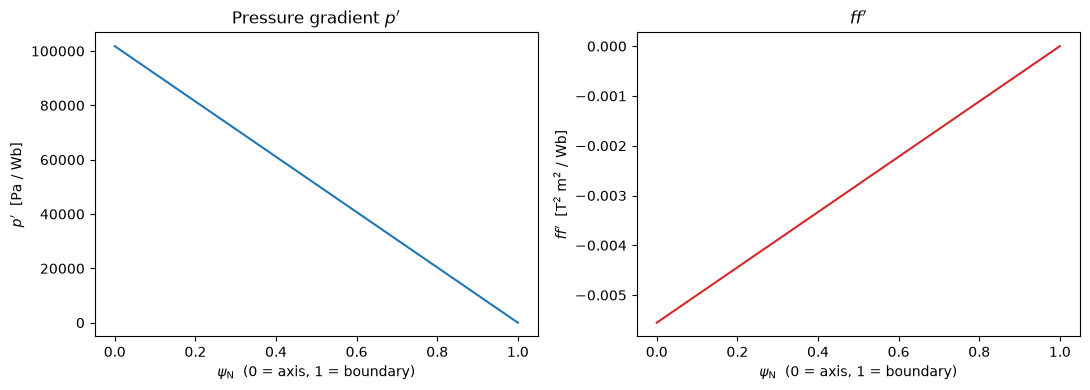

In [8]:
# --- Free-function derivatives p' and ff' vs normalised flux ---
# IMAS convention: derivatives with respect to the total poloidal flux [weber]
profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
profile_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)
profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)

fig, (ax_p_prime, ax_ff_prime) = plt.subplots(1, 2, figsize=(11, 4))

ax_p_prime.plot(profile_psi_n, profile_p_prime, color="tab:blue")
ax_p_prime.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_p_prime.set_ylabel("$p'$  [Pa / Wb]")
ax_p_prime.set_title("Pressure gradient $p'$")

ax_ff_prime.plot(profile_psi_n, profile_ff_prime, color="tab:red")
ax_ff_prime.set_xlabel("$\\psi_\\mathrm{N}$  (0 = axis, 1 = boundary)")
ax_ff_prime.set_ylabel("$ff'$  [T$^2$ m$^2$ / Wb]")
ax_ff_prime.set_title("$ff'$")

fig.tight_layout()
plt.show()

In [9]:
# --- Reconstruct the GF equilibrium with GSFit from the synthetic coils + magnetics ---
# Feed the fitted PF coils and the synthetic BP probes / flux loops into the GSFit inverse
# Grad-Shafranov solver. Every other sensor family (Rogowski, pressure, isoflux, ...) is created
# but left empty. Requires the get_coils cell (which also builds `wall`) and the synthetic-sensor cell above.
import time as time_py

import gsfit_rs
from gsfit_rs import Coils, Dialoop, Isoflux, IsofluxBoundary, Passives, Plasma, Pressure, RogowskiCoils, StationaryPoint, Tf, solve_grad_shafranov

# --- Initial guess: the GF plasma current and magnetic axis ---
# The fitted coils reproduce the field of the FULL plasma current, so the seed blob must carry a
# realistic current to form a confined region against them.
ip_gf = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.ip)
print(f"GF plasma current (seed): {ip_gf / 1.0e3:.1f} kA;  magnetic axis R = {mag_r:.3f} m")

# --- Coils: one single-filament PF coil per fitted GF boundary node ---
# Rebuilt rather than reusing `gf_coils`, whose single time point cannot be interpolated onto the reconstruction times
coils = Coils()
for i_coil in range(n_coil):
    coils.add_pf_coil(
        name=gf_coil_names[i_coil],
        r=np.array([coil_r[i_coil]]),
        z=np.array([coil_z[i_coil]]),
        d_r=np.array([1.0e-3]),
        d_z=np.array([1.0e-3]),
        time=np.array([0.0, 1.0]),
        measured=np.array([coil_current[i_coil], coil_current[i_coil]]),
    )

# --- Toroidal field: the `tf` IDS holds f_vac = R0 * B_phi0, quoted at the reference radius R0 = r_geo ---
f_vac = r_geo * b_vacuum  # [tesla * metre]
tf = Tf()
tf.set_r0(r_geo)
tf.set_b_field_phi_vacuum_r(time=np.array([0.0, 1.0]), data=np.array([f_vac, f_vac]))

# --- Plasma: reconstruction grid, EFIT-polynomial p' / ff' source functions, and solver numerics ---
# GF p' and ff' are linear in psi_norm, so 2 polynomial degrees of freedom reproduce them exactly.
no_regularisation = np.zeros((1, 2))
p_prime_source_function = gsfit_rs.EfitPolynomial(2, no_regularisation)
ff_prime_source_function = gsfit_rs.EfitPolynomial(2, no_regularisation)

# GSFit grid: slightly inside the GF grid so the fitted coils sit strictly OUTSIDE it (the coils lie
# on the GF grid boundary; keeping them off the solve grid avoids Greens self-term singularities).
gs_r_min, gs_r_max = 0.05, 1.60
gs_z_min, gs_z_max = -1.68, 1.68
gs_n_r, gs_n_z = 65, 135

plasma = Plasma(
    n_r=gs_n_r,
    n_z=gs_n_z,
    r_min=gs_r_min,
    r_max=gs_r_max,
    z_min=gs_z_min,
    z_max=gs_z_max,
    psi_norm=np.linspace(0.0, 1.0, 100),
    p_prime_source_function=p_prime_source_function,
    ff_prime_source_function=ff_prime_source_function,
    initial_guess_ip=ip_gf,  # [ampere]
    initial_guess_cur_r=mag_r,  # [metre]
    initial_guess_cur_z=0.0,  # [metre] (up-down symmetric)
    initial_guess_minor_radius=0.4,  # [metre]
    initial_guess_elongation=1.9,  # [dimensionless]
    n_iter_max=80,
    n_iter_min=0,
    grad_shafranov_deviation_tolerance=5.0e-6,
    nonlinear_solver_method="picard",
    picard_n_iter_no_vertical_feedback=1,
    picard_apply_anderson_mixing=False,
    picard_anderson_n_history=5,
    picard_anderson_mixing=1.0,
    newton_krylov_picard_handover=1.0e-2,
    newton_krylov_n_krylov_max=10,
    newton_krylov_krylov_tolerance=0.1,
    newton_krylov_finite_difference_step=1.0,
    newton_krylov_verbose=False,
    newton_picard_n_basis_max=10,
    newton_picard_contraction_threshold=0.5,
    newton_picard_finite_difference_step=1.0,
    newton_picard_verbose=False,
    times_to_reconstruct=np.array([0.0]),  # [second]; one equilibrium time-slice is allocated per time
)

# --- Sensor families the solver requires but that we leave empty for this test ---
passives = Passives()
rogowski_coils = RogowskiCoils()
pressure_sensors = Pressure()
isoflux = Isoflux()
isoflux_boundary = IsofluxBoundary()
stationary_point = StationaryPoint()
dialoop = Dialoop()

# --- Greens functions between every current source and every sensor ---
plasma.greens_with_coils(coils)
bp_probes.greens_with_coils(coils)
flux_loops.greens_with_coils(coils)
rogowski_coils.greens_with_coils(coils)
isoflux.greens_with_coils(coils)
isoflux_boundary.greens_with_coils(coils)
pressure_sensors.greens_with_coils(coils)
stationary_point.greens_with_coils(coils)

plasma.greens_with_passives(passives)
bp_probes.greens_with_passives(passives)
flux_loops.greens_with_passives(passives)
rogowski_coils.greens_with_passives(passives)
isoflux.greens_with_passives(passives)
isoflux_boundary.greens_with_passives(passives)
pressure_sensors.greens_with_passives(passives)
stationary_point.greens_with_passives(passives)

bp_probes.greens_with_plasma(plasma)
flux_loops.greens_with_plasma(plasma)
rogowski_coils.greens_with_plasma(plasma)
isoflux.greens_with_plasma(plasma)
isoflux_boundary.greens_with_plasma(plasma)
pressure_sensors.greens_with_plasma(plasma)
stationary_point.greens_with_plasma(plasma)

# --- Solve the inverse Grad-Shafranov problem (mutates plasma and the sensor objects) ---
# The reconstruction times and numerics are read from `plasma`, the toroidal field from `tf`, and the limiter from `wall`.
tic = time_py.time()
solve_grad_shafranov(
    plasma=plasma,
    wall=wall,
    tf=tf,
    coils=coils,
    passives=passives,
    bp_probes=bp_probes,
    flux_loops=flux_loops,
    rogowski_coils=rogowski_coils,
    isoflux=isoflux,
    isoflux_boundary=isoflux_boundary,
    pressure_sensors=pressure_sensors,
    stationary_point=stationary_point,
    dialoop=dialoop,
)
print(f"GSFit inverse solve finished in {time_py.time() - tic:.2f} s")

GF plasma current (seed): 454.0 kA;  magnetic axis R = 1.079 m
GSFit inverse solve finished in 2.26 s


BP probe  fit RMS residual: 1.043e-06 T  (0.001% of span)
flux loop fit RMS residual: 2.051e-06 Wb (0.002% of span)


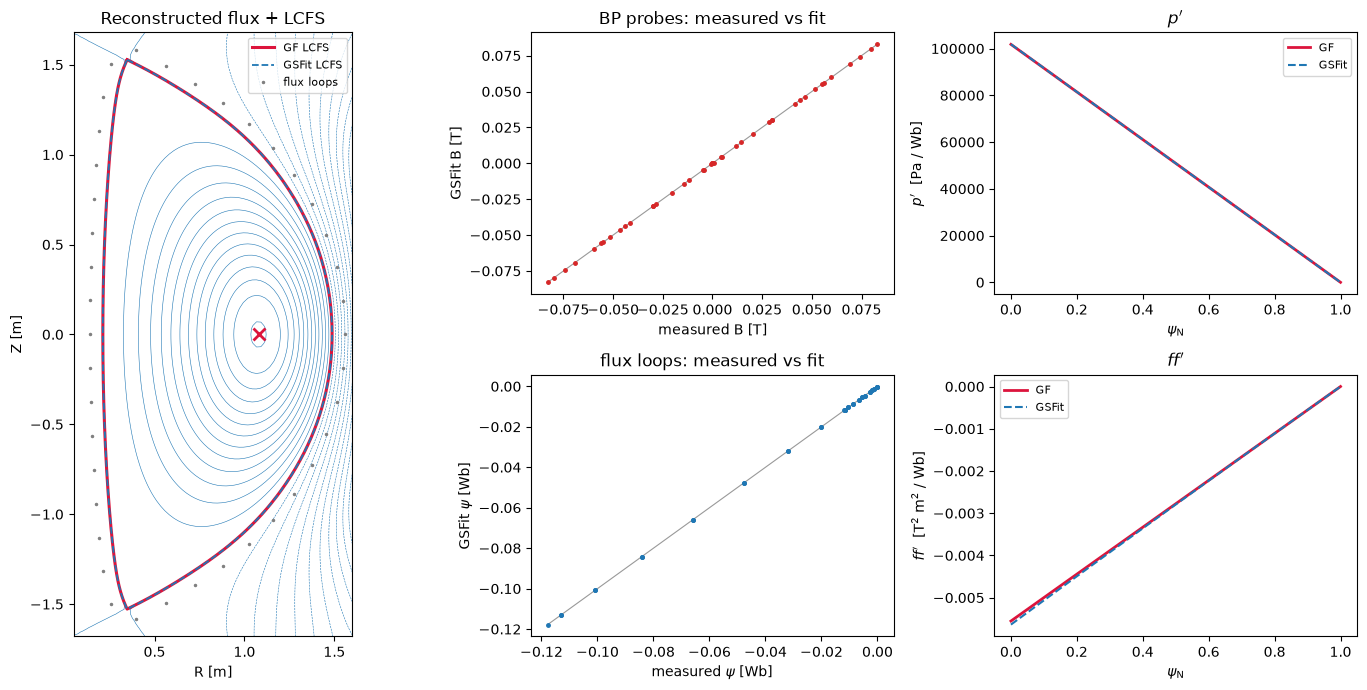

In [10]:
# --- Validate: GSFit reconstruction vs the GF free-boundary equilibrium ---
# The equilibrium IDS is a snapshot copy, so read it once after the solve
gsfit_equilibrium_ids = plasma.equilibrium_ids

gsfit_time = gsfit_equilibrium_ids.get(ep.time_slice[:].time)
i_time = int(np.argmin(np.abs(gsfit_time - 0.0)))

# `profiles_2d[0]` because GSFit solves on a single rectangular (R, Z) grid
gsfit_grid_r = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].grid.dim1)
gsfit_grid_z = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].grid.dim2)
gsfit_psi = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_2d[0].psi)
# The IDS stores each time-slice's boundary at its true length, so no trimming is needed
gsfit_boundary_r = gsfit_equilibrium_ids.get(ep.time_slice[i_time].boundary.outline.r)
gsfit_boundary_z = gsfit_equilibrium_ids.get(ep.time_slice[i_time].boundary.outline.z)

gf_boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)
gf_boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)

# --- Sensor fit quality: measured (from GF) vs calculated (GSFit forward model) ---
bp_measured = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[i_time] for name in bp_probe_names])
bp_fit = np.array([bp_probes.get_array1([name, "b", "calculated", "value"])[i_time] for name in bp_probe_names])
fl_measured = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[i_time] for name in flux_loop_names])
fl_fit = np.array([flux_loops.get_array1([name, "psi", "calculated", "value"])[i_time] for name in flux_loop_names])
bp_rms = np.sqrt(np.mean((bp_fit - bp_measured) ** 2))
fl_rms = np.sqrt(np.mean((fl_fit - fl_measured) ** 2))
print(f"BP probe  fit RMS residual: {bp_rms:.3e} T  ({100 * bp_rms / (bp_measured.max() - bp_measured.min()):.3f}% of span)")
print(f"flux loop fit RMS residual: {fl_rms:.3e} Wb ({100 * fl_rms / (fl_measured.max() - fl_measured.min()):.3f}% of span)")

# --- Reconstructed vs GF profiles. Both IDSs follow the IMAS convention, derivatives with respect to the total flux [weber] ---
gf_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)
gf_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)
gf_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)
gsfit_psi_n = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.psi_norm)
gsfit_p_prime = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.dpressure_dpsi)
gsfit_ff_prime = gsfit_equilibrium_ids.get(ep.time_slice[i_time].profiles_1d.f_df_dpsi)

fig = plt.figure(figsize=(14, 7))
grid_spec = fig.add_gridspec(2, 3, width_ratios=[1.2, 1.0, 1.0])
ax_eq = fig.add_subplot(grid_spec[:, 0])
ax_bp = fig.add_subplot(grid_spec[0, 1])
ax_fl = fig.add_subplot(grid_spec[1, 1])
ax_pp = fig.add_subplot(grid_spec[0, 2])
ax_ffp = fig.add_subplot(grid_spec[1, 2])

# Equilibrium overlay
ax_eq.contour(gsfit_grid_r, gsfit_grid_z, gsfit_psi, levels=25, colors="tab:blue", linewidths=0.4)
ax_eq.plot(gf_boundary_r, gf_boundary_z, color="crimson", lw=2.2, label="GF LCFS")
ax_eq.plot(gsfit_boundary_r, gsfit_boundary_z, color="tab:blue", lw=1.3, ls="--", label="GSFit LCFS")
ax_eq.plot(flux_loop_r, flux_loop_z, ".", color="0.5", ms=3, label="flux loops")
ax_eq.plot(mag_r, mag_z, "x", color="crimson", ms=8, mew=2)
ax_eq.set_aspect("equal")
ax_eq.set_xlabel("R [m]")
ax_eq.set_ylabel("Z [m]")
ax_eq.set_title("Reconstructed flux + LCFS")
ax_eq.legend(loc="upper right", fontsize=8)

# BP probe fit
bp_lims = [min(bp_measured.min(), bp_fit.min()), max(bp_measured.max(), bp_fit.max())]
ax_bp.plot(bp_lims, bp_lims, color="0.6", lw=0.8)
ax_bp.plot(bp_measured, bp_fit, ".", color="tab:red", ms=5)
ax_bp.set_xlabel("measured B [T]")
ax_bp.set_ylabel("GSFit B [T]")
ax_bp.set_title("BP probes: measured vs fit")

# Flux loop fit
fl_lims = [min(fl_measured.min(), fl_fit.min()), max(fl_measured.max(), fl_fit.max())]
ax_fl.plot(fl_lims, fl_lims, color="0.6", lw=0.8)
ax_fl.plot(fl_measured, fl_fit, ".", color="tab:blue", ms=5)
ax_fl.set_xlabel("measured $\\psi$ [Wb]")
ax_fl.set_ylabel("GSFit $\\psi$ [Wb]")
ax_fl.set_title("flux loops: measured vs fit")

# Profiles
ax_pp.plot(gf_psi_n, gf_p_prime, color="crimson", lw=2.0, label="GF")
ax_pp.plot(gsfit_psi_n, gsfit_p_prime, color="tab:blue", ls="--", label="GSFit")
ax_pp.set_xlabel("$\\psi_\\mathrm{N}$")
ax_pp.set_ylabel("$p'$  [Pa / Wb]")
ax_pp.set_title("$p'$")
ax_pp.legend(fontsize=8)

ax_ffp.plot(gf_psi_n, gf_ff_prime, color="crimson", lw=2.0, label="GF")
ax_ffp.plot(gsfit_psi_n, gsfit_ff_prime, color="tab:blue", ls="--", label="GSFit")
ax_ffp.set_xlabel("$\\psi_\\mathrm{N}$")
ax_ffp.set_ylabel("$ff'$  [T$^2$ m$^2$ / Wb]")
ax_ffp.set_title("$ff'$")
ax_ffp.legend(fontsize=8)

fig.tight_layout()
plt.show()

In [11]:
# --- Save the data behind the synthetic magnetic diagnostics figure, for the standalone paper plotter ---
# `paper_figures/plot_synthetic_magnetic_diagnostics.py` redraws the figure from this file alone (numpy + matplotlib).
# The GF equilibrium and sensor geometry come from the get_coils and synthetic-sensor cells; the GSFit equilibrium and reconstructed sensor values from the GSFit reconstruction above.
# Run before the grid scan, which overwrites the sensors' "calculated" values.
# The path is relative to this notebook's directory, which is the working directory of its kernel.
from pathlib import Path

# GF: the free-boundary total flux (plasma + fitted PF coils), which is valid in the vacuum as well as the plasma
gf_psi = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)  # [weber], shape (n_z, n_r)
gf_psi_magnetic_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)  # [weber]
# The scrape-off layer legs, traced from the active X-point to the wall; empty for a limited plasma
gf_sol_hfs_contour_r = gf_equilibrium_ids.get(ep.time_slice[0].sol.hfs.contour.r)  # [metre]
gf_sol_hfs_contour_z = gf_equilibrium_ids.get(ep.time_slice[0].sol.hfs.contour.z)  # [metre]
gf_sol_lfs_contour_r = gf_equilibrium_ids.get(ep.time_slice[0].sol.lfs.contour.r)  # [metre]
gf_sol_lfs_contour_z = gf_equilibrium_ids.get(ep.time_slice[0].sol.lfs.contour.z)  # [metre]

# GSFit: the reconstruction of the single time-slice. The equilibrium IDS is a snapshot copy, so read it once
gsfit_equilibrium_ids = plasma.equilibrium_ids
gsfit_grid_r = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].grid.dim1)  # [metre]
gsfit_grid_z = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].grid.dim2)  # [metre]
gsfit_psi = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)  # [weber], shape (n_z, n_r)
gsfit_lcfs_r = gsfit_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)  # [metre]
gsfit_lcfs_z = gsfit_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)  # [metre]
gsfit_sol_hfs_contour_r = gsfit_equilibrium_ids.get(ep.time_slice[0].sol.hfs.contour.r)  # [metre]
gsfit_sol_hfs_contour_z = gsfit_equilibrium_ids.get(ep.time_slice[0].sol.hfs.contour.z)  # [metre]
gsfit_sol_lfs_contour_r = gsfit_equilibrium_ids.get(ep.time_slice[0].sol.lfs.contour.r)  # [metre]
gsfit_sol_lfs_contour_z = gsfit_equilibrium_ids.get(ep.time_slice[0].sol.lfs.contour.z)  # [metre]

# The measured (synthetic, from GF) and reconstructed (GSFit forward model) values of the single reconstructed time-slice
flux_loop_names = flux_loops.keys()
flux_loop_psi_measured = np.array([flux_loops.get_array1([name, "psi", "experimental", "value"])[0] for name in flux_loop_names])  # [weber]
flux_loop_psi_reconstructed = np.array([flux_loops.get_array1([name, "psi", "calculated", "value"])[0] for name in flux_loop_names])  # [weber]
bp_probe_names = bp_probes.keys()
bp_probe_b_measured = np.array([bp_probes.get_array1([name, "b", "experimental", "value"])[0] for name in bp_probe_names])  # [tesla]
bp_probe_b_reconstructed = np.array([bp_probes.get_array1([name, "b", "calculated", "value"])[0] for name in bp_probe_names])  # [tesla]

paper_figures_path = Path("paper_figures")
paper_figures_path.mkdir(exist_ok=True)
np.savez_compressed(
    paper_figures_path / "synthetic_magnetic_diagnostics.npz",
    gf_grid_r=r,  # [metre], shape (n_r,)
    gf_grid_z=z,  # [metre], shape (n_z,)
    gf_psi=gf_psi,  # [weber], shape (n_z, n_r)
    gf_psi_magnetic_axis=gf_psi_magnetic_axis,  # [weber]
    gf_lcfs_r=lcfs_r,  # [metre]
    gf_lcfs_z=lcfs_z,  # [metre]
    gf_magnetic_axis_r=mag_r,  # [metre]; the origin of the sensors' poloidal angle
    gf_magnetic_axis_z=mag_z,  # [metre]
    gf_sol_hfs_contour_r=gf_sol_hfs_contour_r,  # [metre]
    gf_sol_hfs_contour_z=gf_sol_hfs_contour_z,  # [metre]
    gf_sol_lfs_contour_r=gf_sol_lfs_contour_r,  # [metre]
    gf_sol_lfs_contour_z=gf_sol_lfs_contour_z,  # [metre]
    pf_coil_r=coil_r,  # fitted GF PF coil filaments [metre]
    pf_coil_z=coil_z,  # fitted GF PF coil filaments [metre]
    gsfit_grid_r=gsfit_grid_r,  # [metre], shape (n_r,)
    gsfit_grid_z=gsfit_grid_z,  # [metre], shape (n_z,)
    gsfit_psi=gsfit_psi,  # [weber], shape (n_z, n_r)
    gsfit_lcfs_r=gsfit_lcfs_r,  # [metre]
    gsfit_lcfs_z=gsfit_lcfs_z,  # [metre]
    gsfit_sol_hfs_contour_r=gsfit_sol_hfs_contour_r,  # [metre]
    gsfit_sol_hfs_contour_z=gsfit_sol_hfs_contour_z,  # [metre]
    gsfit_sol_lfs_contour_r=gsfit_sol_lfs_contour_r,  # [metre]
    gsfit_sol_lfs_contour_z=gsfit_sol_lfs_contour_z,  # [metre]
    flux_loop_r=flux_loop_r,  # [metre]
    flux_loop_z=flux_loop_z,  # [metre]
    flux_loop_psi_measured=flux_loop_psi_measured,  # [weber]
    flux_loop_psi_reconstructed=flux_loop_psi_reconstructed,  # [weber]
    bp_probe_r=bp_probe_r,  # [metre]
    bp_probe_z=bp_probe_z,  # [metre]
    bp_probe_angle_pol=bp_probe_angle,  # poloidal orientation [radian]
    bp_probe_b_measured=bp_probe_b_measured,  # [tesla]
    bp_probe_b_reconstructed=bp_probe_b_reconstructed,  # [tesla]
)
print(f"saved {paper_figures_path / 'synthetic_magnetic_diagnostics.npz'}")

saved paper_figures\synthetic_magnetic_diagnostics.npz


In [ ]:
# --- Save the p' and ff' profiles of the GF and GSFit equilibria, with their psi_N, for the standalone paper plotter ---
# Both IDSs follow the IMAS convention: derivatives with respect to the total poloidal flux [weber]. Each code has its
# own psi_N grid, so both are saved. The GSFit equilibrium is the reconstruction of the single time-slice above.
# The path is relative to this notebook's directory, which is the working directory of its kernel.
from pathlib import Path

gf_psi_norm = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)  # [dimensionless]
gf_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)  # [pascal / weber]
gf_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)  # [tesla^2 * metre^2 / weber]

# The equilibrium IDS is a snapshot copy, so read it once
gsfit_equilibrium_ids = plasma.equilibrium_ids
gsfit_psi_norm = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)  # [dimensionless]
gsfit_p_prime = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)  # [pascal / weber]
gsfit_ff_prime = gsfit_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)  # [tesla^2 * metre^2 / weber]

paper_figures_path = Path("paper_figures")
paper_figures_path.mkdir(exist_ok=True)
np.savez_compressed(
    paper_figures_path / "p_prime_ff_prime_profiles.npz",
    gf_psi_norm=gf_psi_norm,  # [dimensionless], 0 on the magnetic axis and 1 on the boundary
    gf_p_prime=gf_p_prime,  # [pascal / weber]
    gf_ff_prime=gf_ff_prime,  # [tesla^2 * metre^2 / weber]
    gsfit_psi_norm=gsfit_psi_norm,  # [dimensionless], 0 on the magnetic axis and 1 on the boundary
    gsfit_p_prime=gsfit_p_prime,  # [pascal / weber]
    gsfit_ff_prime=gsfit_ff_prime,  # [tesla^2 * metre^2 / weber]
)
print(f"saved {paper_figures_path / 'p_prime_ff_prime_profiles.npz'}")

Z grid: max |z + z[::-1]|                       = 3.331e-16 m
1. analytic solution
   plasma mask cells that differ from mirror    = 0
   psi_analytic, inside the plasma              = 5.635e-16
2. fitted PF coils
   coil position vs mirror coil                 = 3.331e-16 m
   coil current vs mirror coil (/ max |I|)      = 7.013e-07
3. total flux (plasma + coils)
   psi_total, whole grid                        = 1.483e-07
   psi_total, inside the plasma                 = 1.491e-10
4. post-processor
   magnetic axis Z                              = -6.681e-11 m
   boundary geometric axis Z                    = 3.272e-11 m
   boundary vs its mirror image (max distance)  = 4.127e-09 m  (0.000 d_z)
   triangularity   upper / lower                = 0.787923 / 0.787923
   squareness inner upper / lower               = -0.076263 / -0.076263
   squareness outer upper / lower               = -0.174565 / -0.174565


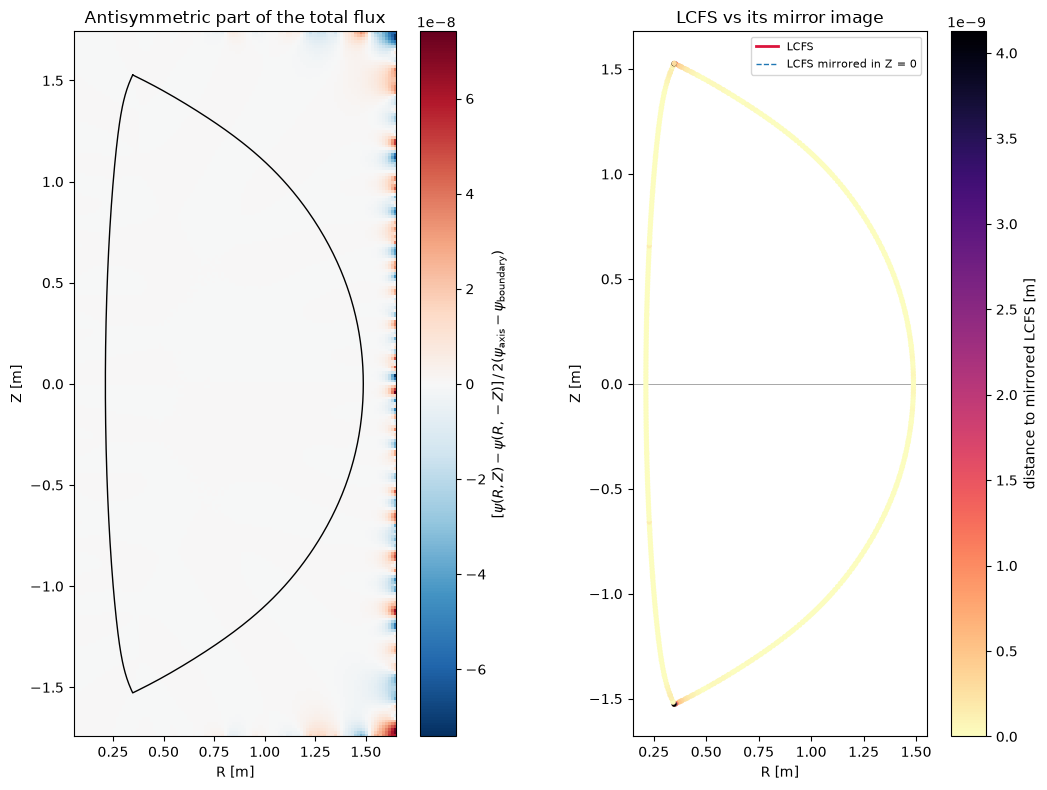

In [12]:
# --- Is the GF free-boundary equilibrium up/down symmetric? ---
# The double-null GF flux is even in y = Z / a by construction, so every stage should be a mirror image of itself about Z = 0:
# the analytic solution from `solve()`, the fitted PF coils, the total flux, and the boundary the post-processor traces from it.
# Each check prints the largest difference between a quantity and its mirror image; flux differences are normalised by psi_axis - psi_boundary.


def distance_to_closed_curve(point_r, point_z, curve_r, curve_z):
    """Shortest distance [metre] from each point (point_r, point_z) to the closed polyline through (curve_r, curve_z)."""
    curve_r = np.append(curve_r, curve_r[0])
    curve_z = np.append(curve_z, curve_z[0])
    segment_start_r = curve_r[np.newaxis, :-1]
    segment_start_z = curve_z[np.newaxis, :-1]
    segment_d_r = np.diff(curve_r)[np.newaxis, :]
    segment_d_z = np.diff(curve_z)[np.newaxis, :]
    segment_length_squared = np.maximum(segment_d_r**2 + segment_d_z**2, 1.0e-30)
    # Position of the closest point along each segment: 0 = segment start, 1 = segment end
    segment_fraction = np.clip(
        ((point_r[:, np.newaxis] - segment_start_r) * segment_d_r + (point_z[:, np.newaxis] - segment_start_z) * segment_d_z) / segment_length_squared,
        0.0,
        1.0,
    )
    distance = np.hypot(
        segment_start_r + segment_fraction * segment_d_r - point_r[:, np.newaxis],
        segment_start_z + segment_fraction * segment_d_z - point_z[:, np.newaxis],
    )
    return np.min(distance, axis=1)


# `field[::-1, :]` is the mirror image of a grid quantity only if the Z grid is itself symmetric
z_grid_mismatch = np.max(np.abs(z + z[::-1]))  # [metre]
d_z = z[1] - z[0]  # [metre]
psi_scale = abs(psi_axis - psi_boundary)  # [weber]

# 1. Analytic solution. Compared only inside the plasma, as the truncated series diverges outside it
mask_mismatch_count = int(np.sum(mask != mask[::-1, :]))
plasma_and_mirror = (mask > 0) & (mask[::-1, :] > 0)
psi_analytic_mismatch = np.max(np.abs(psi_analytic - psi_analytic[::-1, :])[plasma_and_mirror]) / psi_scale

# 2. Fitted PF coils: pair each coil with the coil closest to its mirror image (R, -Z)
coil_mirror_distance = np.hypot(coil_r[:, np.newaxis] - coil_r[np.newaxis, :], coil_z[:, np.newaxis] + coil_z[np.newaxis, :])  # (n_coil, n_coil)
i_coil_mirror = np.argmin(coil_mirror_distance, axis=1)
coil_position_mismatch = np.max(coil_mirror_distance[np.arange(n_coil), i_coil_mirror])  # [metre]
coil_current_mismatch = np.max(np.abs(coil_current - coil_current[i_coil_mirror])) / np.max(np.abs(coil_current))

# 3. Total flux (plasma + coils), which is valid over the whole grid
psi_total_difference = psi_total - psi_total[::-1, :]  # [weber]
psi_total_mismatch = np.max(np.abs(psi_total_difference)) / psi_scale
psi_total_mismatch_plasma = np.max(np.abs(psi_total_difference)[plasma_and_mirror]) / psi_scale

# 4. Post-processor: the traced boundary and the geometry derived from it
boundary_mirror_distance = distance_to_closed_curve(boundary_r, -boundary_z, boundary_r, boundary_z)  # [metre]
geometric_axis_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.geometric_axis.z)
triangularity_upper = gf_equilibrium_ids.get(ep.time_slice[0].boundary.triangularity_upper)
triangularity_lower = gf_equilibrium_ids.get(ep.time_slice[0].boundary.triangularity_lower)
squareness_upper_inner = gf_equilibrium_ids.get(ep.time_slice[0].boundary.squareness_upper_inner)
squareness_lower_inner = gf_equilibrium_ids.get(ep.time_slice[0].boundary.squareness_lower_inner)
squareness_upper_outer = gf_equilibrium_ids.get(ep.time_slice[0].boundary.squareness_upper_outer)
squareness_lower_outer = gf_equilibrium_ids.get(ep.time_slice[0].boundary.squareness_lower_outer)

print(f"Z grid: max |z + z[::-1]|                       = {z_grid_mismatch:.3e} m")
print("1. analytic solution")
print(f"   plasma mask cells that differ from mirror    = {mask_mismatch_count}")
print(f"   psi_analytic, inside the plasma              = {psi_analytic_mismatch:.3e}")
print("2. fitted PF coils")
print(f"   coil position vs mirror coil                 = {coil_position_mismatch:.3e} m")
print(f"   coil current vs mirror coil (/ max |I|)      = {coil_current_mismatch:.3e}")
print("3. total flux (plasma + coils)")
print(f"   psi_total, whole grid                        = {psi_total_mismatch:.3e}")
print(f"   psi_total, inside the plasma                 = {psi_total_mismatch_plasma:.3e}")
print("4. post-processor")
print(f"   magnetic axis Z                              = {mag_z:.3e} m")
print(f"   boundary geometric axis Z                    = {geometric_axis_z:.3e} m")
print(f"   boundary vs its mirror image (max distance)  = {np.max(boundary_mirror_distance):.3e} m  ({np.max(boundary_mirror_distance) / d_z:.3f} d_z)")
print(f"   triangularity   upper / lower                = {triangularity_upper:.6f} / {triangularity_lower:.6f}")
print(f"   squareness inner upper / lower               = {squareness_upper_inner:.6f} / {squareness_lower_inner:.6f}")
print(f"   squareness outer upper / lower               = {squareness_upper_outer:.6f} / {squareness_lower_outer:.6f}")

fig, (ax_psi, ax_boundary) = plt.subplots(1, 2, figsize=(11, 8))

# --- Panel 1: the up/down antisymmetric part of the total flux ---
psi_antisymmetric = 0.5 * psi_total_difference / psi_scale
antisymmetric_abs_max = max(np.max(np.abs(psi_antisymmetric)), 1.0e-300)
fill = ax_psi.pcolormesh(r, z, psi_antisymmetric, cmap="RdBu_r", vmin=-antisymmetric_abs_max, vmax=antisymmetric_abs_max, shading="nearest")
fig.colorbar(fill, ax=ax_psi, label="$[\\psi(R, Z) - \\psi(R, -Z)] \\, / \\, 2 (\\psi_\\mathrm{axis} - \\psi_\\mathrm{boundary})$")
ax_psi.plot(boundary_r, boundary_z, color="k", lw=1.0)
ax_psi.set_aspect("equal")
ax_psi.set_xlabel("R [m]")
ax_psi.set_ylabel("Z [m]")
ax_psi.set_title("Antisymmetric part of the total flux")

# --- Panel 2: the traced boundary and its mirror image, coloured by how far each point is from the mirror ---
ax_boundary.plot(boundary_r, boundary_z, color="crimson", lw=2.0, label="LCFS")
ax_boundary.plot(boundary_r, -boundary_z, color="tab:blue", lw=1.0, ls="--", label="LCFS mirrored in Z = 0")
distance_scatter = ax_boundary.scatter(boundary_r, boundary_z, c=boundary_mirror_distance, cmap="magma_r", s=8, zorder=5)
fig.colorbar(distance_scatter, ax=ax_boundary, label="distance to mirrored LCFS [m]")
ax_boundary.axhline(0.0, color="0.6", lw=0.6)
ax_boundary.set_aspect("equal")
ax_boundary.set_xlabel("R [m]")
ax_boundary.set_ylabel("Z [m]")
ax_boundary.set_title("LCFS vs its mirror image")
ax_boundary.legend(loc="upper right", fontsize=8)

fig.tight_layout()
plt.show()

In [13]:
# --- Grid sensitivity scan, 1 of 4: the GSFit grid for a given grid spacing ---
# The scan changes only the GSFit grid spacing. The Guazzotto-Freidberg grid is kept fixed, so the analytic ground truth and the fitted PF coils do not change.
# `r_min` is the same for every grid spacing, while `r_max` and `z_max = -z_min` change so that the cells stay square.


def calculate_grid(
    d_grid: float,
    r_min: float,
    inner_r_min: float,
    inner_r_max: float,
    inner_z_max: float,
    outer_r_min: float,
    outer_r_max: float,
    outer_z_max: float,
) -> dict[str, int | float]:
    """
    Calculate the grid inputs for the `Plasma` constructor, with square cells d_r = d_z = d_grid.

    The grid starts at the fixed `r_min` and grows outwards, so only `r_max` changes with the grid spacing.
    The grid is up-down symmetric, z_min = -z_max, with an even number of Z grid points so that Z = 0 lies midway between two grid rows.
    With Z = 0 on a grid row, the magnetic axis of this (almost exactly) up-down symmetric equilibrium sits on the row, where the
    stationary point search is fragile: some grid spacings then fail with `NoMagneticAxisFound` or `NoBoundaryFound`.
    The grid strictly encloses the inner box, so every limiter point has grid points on both sides of it.
    On the outboard side the second-to-last R grid point must also be beyond the inner box: the limit point search in
    `rust/gsfit_rs/src/plasma_geometry/find_viable_limit_point.rs` marches out along the midplane with `index_mag_r..n_r - 1`, which never reaches the last column.
    Without that column no limit point is viable on the first iteration, and the solve fails with `NoBoundaryFound`.
    The grid lies strictly inside the outer box, so the PF coils stay outside it.
    It uses the fewest grid points which do all of this.

    :param d_grid: Grid spacing in both R and Z [metre]
    :param r_min: Minimum R of the grid, the same for every grid spacing [metre]
    :param inner_r_min: Minimum R of the box the grid must enclose [metre]
    :param inner_r_max: Maximum R of the box the grid must enclose [metre]
    :param inner_z_max: Maximum |Z| of the box the grid must enclose [metre]
    :param outer_r_min: Minimum R of the box the grid must stay inside [metre]
    :param outer_r_max: Maximum R of the box the grid must stay inside [metre]
    :param outer_z_max: Maximum |Z| of the box the grid must stay inside [metre]
    :return: `n_r`, `n_z` [dimensionless] and `r_min`, `r_max`, `z_min`, `z_max` [metre]; the same keys as `settings["GSFIT_code_settings.json"]["grid"]`
    """
    if not outer_r_min < r_min < inner_r_min:
        raise ValueError(f"calculate_grid: r_min = {r_min} m must lie between outer_r_min = {outer_r_min} m and inner_r_min = {inner_r_min} m")
    # `Plasma` does not allow grid cells at negative R
    if r_min - 0.5 * d_grid < 0.0:
        raise ValueError(f"calculate_grid: d_grid = {d_grid} m gives r_min - d_grid / 2 = {r_min - 0.5 * d_grid} m, but grid cells must not reach negative R")

    # R: the fewest intervals which reach strictly beyond the inner box, plus one, so the second-to-last R grid point is beyond it too
    n_r_interval = int(np.floor((inner_r_max - r_min) / d_grid)) + 2
    r_max = r_min + n_r_interval * d_grid  # [metre]
    # Z: grid rows at Z = (i_z + 0.5) * d_grid for i_z = -n_z_half, ..., n_z_half - 1; the fewest rows which reach strictly beyond the inner box
    n_z_half = int(np.floor(inner_z_max / d_grid + 0.5)) + 1
    z_max = (n_z_half - 0.5) * d_grid  # [metre]
    if r_max - d_grid <= inner_r_max or z_max <= inner_z_max:
        raise ValueError(f"calculate_grid: d_grid = {d_grid} m gives r_max = {r_max} m and z_max = {z_max} m, which do not enclose the inner box")
    if r_max >= outer_r_max or z_max >= outer_z_max:
        raise ValueError(
            f"calculate_grid: d_grid = {d_grid} m gives r_max = {r_max:.4f} m and z_max = {z_max:.4f} m, "
            f"which must be below outer_r_max = {outer_r_max:.4f} m and outer_z_max = {outer_z_max:.4f} m"
        )

    grid = {
        "n_r": n_r_interval + 1,
        "n_z": 2 * n_z_half,
        "r_min": r_min,
        "r_max": r_max,
        "z_min": -z_max,
        "z_max": z_max,
    }
    return grid


# Inner box: the wall, so every limiter point is inside the GSFit grid.
# Outer box: the GF grid, whose boundary nodes hold the fitted PF coils.
grid_boxes = {
    "inner_r_min": float(limiter_r.min()),
    "inner_r_max": float(limiter_r.max()),
    "inner_z_max": float(np.abs(limiter_z).max()),
    "outer_r_min": gf.r_min,
    "outer_r_max": gf.r_max,
    "outer_z_max": min(-gf.z_min, gf.z_max),
}
# Between the inner PF coils and the wall
grid_r_min = 0.09  # [metre]

gf_d_r = (gf.r_max - gf.r_min) / (gf.n_r - 1)  # [metre]
gf_d_z = (gf.z_max - gf.z_min) / (gf.n_z - 1)  # [metre]
print(f"GF grid (ground truth, fixed): {gf.n_r} x {gf.n_z}, d_r = {gf_d_r * 1.0e3:.2f} mm, d_z = {gf_d_z * 1.0e3:.2f} mm")
print(f"GSFit grid boxes: {grid_boxes};  r_min = {grid_r_min} m")

GF grid (ground truth, fixed): 114 x 249, d_r = 14.00 mm, d_z = 14.00 mm
GSFit grid boxes: {'inner_r_min': 0.12, 'inner_r_max': 1.55, 'inner_z_max': 1.62, 'outer_r_min': 0.06250000000000003, 'outer_r_max': 1.6445, 'outer_z_max': 1.736};  r_min = 0.09 m


In [ ]:
# --- Grid sensitivity scan, 2 of 4: reconstruct the GF equilibrium over a range of GSFit grid spacings ---
# Only the GSFit grid changes between scan points. The coils, synthetic sensors, wall, toroidal field, source functions and solver numerics are the ones from the reconstruction above.
# The GF equilibrium is not recalculated, so its beta_pol_3, plasma volume and MHD energy are the same ground truth for every grid.
# Note: this overwrites the sensors' plasma Greens and "calculated" values from the reconstruction above, so re-run that cell before the validation cell.
import ctypes
import gc

# Memory: on the shared machine all of a user's processes share one memory limit, so the grid size is capped at what has been measured to be safe.
# Measured kernel peaks (including ~2.5 GiB held by the GF equilibrium): 76 x 164 -> 3.8 GiB, 115 x 252 -> 6.0 GiB, 135 x 296 -> 7.5 GiB; ~156 x 342 was killed at ~9 GiB.
n_grid_limit = 135 * 296  # [dimensionless]; maximum n_r * n_z
d_grid_fine = 0.011  # [metre]; gives 135 x 296
# The coarsest spacing is set by the gap between the wall and the PF coils: r_max must lie between inner_r_max + d_grid and outer_r_max, which is only possible for d_grid < ~0.08 m
d_grid_coarse = 0.08  # [metre]

# 100 candidates equally spaced in log(d_grid), so they are equally spaced on the log axis of the figure.
# Finest first, so the largest grid is solved while the least memory has been used.
# Some coarse spacings have no multiple that fits between the wall and the PF coils; those are skipped
scan_d_grid_candidate = np.geomspace(d_grid_fine, d_grid_coarse, 100)  # [metre]
n_scan_candidate = scan_d_grid_candidate.size
scan_d_grid_list = []
scan_grids = []
for i_scan_candidate in range(n_scan_candidate):
    d_grid = float(scan_d_grid_candidate[i_scan_candidate])
    try:
        grid = calculate_grid(d_grid, grid_r_min, **grid_boxes)
    except ValueError as error:
        print(f"skipping d_grid = {d_grid * 1.0e3:.2f} mm: {error}")
        continue
    if grid["n_r"] * grid["n_z"] > n_grid_limit:
        print(f"skipping d_grid = {d_grid * 1.0e3:.2f} mm: {grid['n_r']} x {grid['n_z']} has more than n_grid_limit = {n_grid_limit} grid points")
        continue
    scan_d_grid_list.append(d_grid)
    scan_grids.append(grid)
scan_d_grid = np.array(scan_d_grid_list)  # [metre]
n_scan = scan_d_grid.size
print(f"{n_scan} of {n_scan_candidate} candidate grid spacings fit")

gf_beta_pol_3 = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.beta_pol_3)
gf_energy_mhd = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.energy_mhd)  # [joule]
gf_volume = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.volume)  # [metre ** 3]

scan_n_r = np.zeros(n_scan, dtype=np.int64)
scan_n_z = np.zeros(n_scan, dtype=np.int64)
scan_r_max = np.full(n_scan, np.nan)  # [metre]
scan_z_max = np.full(n_scan, np.nan)  # [metre]
scan_converged = np.zeros(n_scan, dtype=bool)
scan_n_iter = np.zeros(n_scan, dtype=np.int64)
scan_beta_pol_3 = np.full(n_scan, np.nan)
scan_energy_mhd = np.full(n_scan, np.nan)  # [joule]
scan_volume = np.full(n_scan, np.nan)  # [metre ** 3]
scan_duration = np.full(n_scan, np.nan)  # [second]

# Used to hand memory freed by one scan point back to the operating system before the next, so it does not accumulate.
# `malloc_trim` is glibc's, so on other operating systems (e.g. Windows) this is skipped
try:
    libc = ctypes.CDLL("libc.so.6")
except OSError:
    libc = None

for i_scan in range(n_scan):
    grid = scan_grids[i_scan]
    scan_n_r[i_scan] = grid["n_r"]
    scan_n_z[i_scan] = grid["n_z"]
    scan_r_max[i_scan] = grid["r_max"]
    scan_z_max[i_scan] = grid["z_max"]
    print(f"=== scan {i_scan + 1} / {n_scan}: d_grid = {scan_d_grid[i_scan] * 1.0e3:.2f} mm, {grid['n_r']} x {grid['n_z']} ===")

    tic = time_py.time()
    scan_plasma = Plasma(
        n_r=grid["n_r"],
        n_z=grid["n_z"],
        r_min=grid["r_min"],
        r_max=grid["r_max"],
        z_min=grid["z_min"],
        z_max=grid["z_max"],
        psi_norm=np.linspace(0.0, 1.0, 100),
        p_prime_source_function=gsfit_rs.EfitPolynomial(2, no_regularisation),
        ff_prime_source_function=gsfit_rs.EfitPolynomial(2, no_regularisation),
        initial_guess_ip=ip_gf,  # [ampere]
        initial_guess_cur_r=mag_r,  # [metre]
        initial_guess_cur_z=0.0,  # [metre] (up-down symmetric)
        initial_guess_minor_radius=0.4,  # [metre]
        initial_guess_elongation=1.9,  # [dimensionless]
        n_iter_max=80,
        n_iter_min=0,
        grad_shafranov_deviation_tolerance=5.0e-6,
        nonlinear_solver_method="picard",
        picard_n_iter_no_vertical_feedback=1,
        picard_apply_anderson_mixing=False,
        picard_anderson_n_history=5,
        picard_anderson_mixing=1.0,
        newton_krylov_picard_handover=1.0e-2,
        newton_krylov_n_krylov_max=10,
        newton_krylov_krylov_tolerance=0.1,
        newton_krylov_finite_difference_step=1.0,
        newton_krylov_verbose=False,
        newton_picard_n_basis_max=10,
        newton_picard_contraction_threshold=0.5,
        newton_picard_finite_difference_step=1.0,
        newton_picard_verbose=False,
        times_to_reconstruct=np.array([0.0]),  # [second]
    )

    # The sensors' Greens with the coils and passives do not depend on the grid, so only the Greens involving the plasma are recalculated
    scan_plasma.greens_with_coils(coils)
    scan_plasma.greens_with_passives(passives)
    bp_probes.greens_with_plasma(scan_plasma)
    flux_loops.greens_with_plasma(scan_plasma)
    rogowski_coils.greens_with_plasma(scan_plasma)
    isoflux.greens_with_plasma(scan_plasma)
    isoflux_boundary.greens_with_plasma(scan_plasma)
    pressure_sensors.greens_with_plasma(scan_plasma)
    stationary_point.greens_with_plasma(scan_plasma)

    solve_grad_shafranov(
        plasma=scan_plasma,
        wall=wall,
        tf=tf,
        coils=coils,
        passives=passives,
        bp_probes=bp_probes,
        flux_loops=flux_loops,
        rogowski_coils=rogowski_coils,
        isoflux=isoflux,
        isoflux_boundary=isoflux_boundary,
        pressure_sensors=pressure_sensors,
        stationary_point=stationary_point,
        dialoop=dialoop,
    )
    scan_duration[i_scan] = time_py.time() - tic

    # The equilibrium IDS is a snapshot copy, so read it once per scan point
    scan_equilibrium_ids = scan_plasma.equilibrium_ids
    scan_converged[i_scan] = scan_equilibrium_ids.get(ep.time_slice[0].convergence.result.name) == "converged"
    scan_n_iter[i_scan] = scan_equilibrium_ids.get(ep.time_slice[0].convergence.iterations_n)
    scan_beta_pol_3[i_scan] = scan_equilibrium_ids.get(ep.time_slice[0].global_quantities.beta_pol_3)
    scan_energy_mhd[i_scan] = scan_equilibrium_ids.get(ep.time_slice[0].global_quantities.energy_mhd)
    scan_volume[i_scan] = scan_equilibrium_ids.get(ep.time_slice[0].global_quantities.volume)

    # Free this scan point's plasma and equilibrium before building the next
    del scan_plasma, scan_equilibrium_ids
    gc.collect()
    if libc is not None:
        libc.malloc_trim(0)

# --- Summary ---
print(f"\nGF (ground truth): beta_pol_3 = {gf_beta_pol_3:.6f}, energy_mhd = {gf_energy_mhd:.2f} J, volume = {gf_volume:.6f} m^3;  r_min = {grid_r_min} m for every grid")
print(" d_grid [mm]  n_r x n_z  r_max [m]  z_max [m]  converged  n_iter  beta_pol_3  relative errors: beta_pol_3  energy_mhd      volume  duration [s]")
for i_scan in range(n_scan):
    beta_pol_3_relative_error = (scan_beta_pol_3[i_scan] - gf_beta_pol_3) / gf_beta_pol_3
    energy_mhd_relative_error = (scan_energy_mhd[i_scan] - gf_energy_mhd) / gf_energy_mhd
    volume_relative_error = (scan_volume[i_scan] - gf_volume) / gf_volume
    print(
        f"{scan_d_grid[i_scan] * 1.0e3:12.2f}  {scan_n_r[i_scan]:3d} x {scan_n_z[i_scan]:3d}  {scan_r_max[i_scan]:9.4f}  {scan_z_max[i_scan]:9.4f}"
        f"  {str(scan_converged[i_scan]):>9}  {scan_n_iter[i_scan]:6d}  {scan_beta_pol_3[i_scan]:10.6f}"
        f"  {beta_pol_3_relative_error:+26.3e}  {energy_mhd_relative_error:+10.3e}  {volume_relative_error:+10.3e}  {scan_duration[i_scan]:12.1f}"
    )

skipping d_grid = 55.77 mm: calculate_grid: d_grid = 0.05577219668791593 m gives r_max = 1.6516 m and z_max = 1.6453 m, which must be below outer_r_max = 1.6445 m and outer_z_max = 1.7360 m
skipping d_grid = 58.05 mm: calculate_grid: d_grid = 0.0580531482344723 m gives r_max = 1.6574 m and z_max = 1.6545 m, which must be below outer_r_max = 1.6445 m and outer_z_max = 1.7360 m
skipping d_grid = 60.43 mm: calculate_grid: d_grid = 0.060427385329504577 m gives r_max = 1.6611 m and z_max = 1.6618 m, which must be below outer_r_max = 1.6445 m and outer_z_max = 1.7360 m
skipping d_grid = 62.90 mm: calculate_grid: d_grid = 0.06289872313233409 m gives r_max = 1.6625 m and z_max = 1.6668 m, which must be below outer_r_max = 1.6445 m and outer_z_max = 1.7360 m
skipping d_grid = 65.47 mm: calculate_grid: d_grid = 0.06547113283331692 m gives r_max = 1.6613 m and z_max = 1.6695 m, which must be below outer_r_max = 1.6445 m and outer_z_max = 1.7360 m
skipping d_grid = 68.15 mm: calculate_grid: d_grid

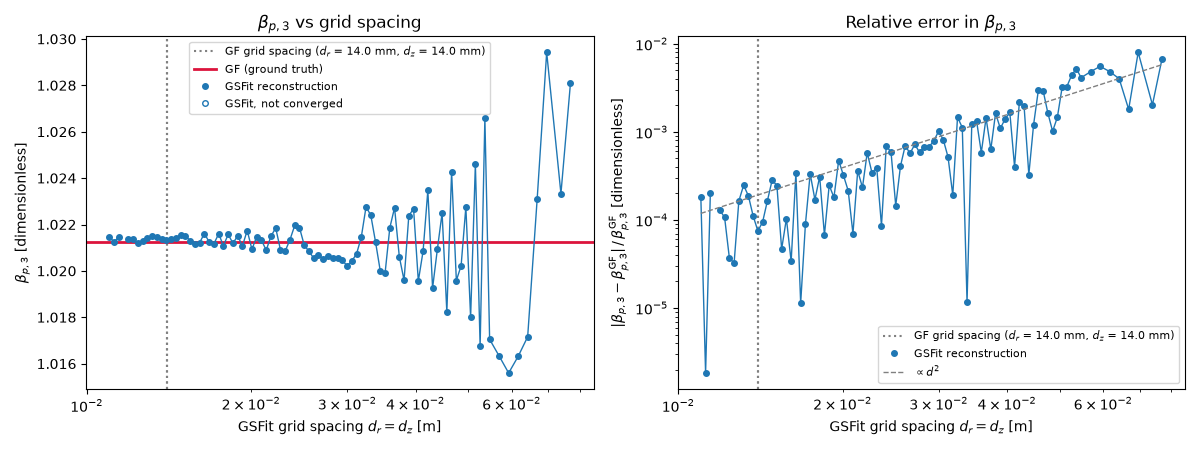

In [ ]:
# --- Grid sensitivity scan, 3 of 4: convergence of beta_pol_3 with GSFit grid spacing ---
# Filled markers converged; hollow markers did not.
# The dotted lines mark the GF grid spacing in R and Z (they coincide for a square GF grid). The GF beta_pol_3 is post-processed on that grid, so it carries its own discretisation error.
# Once the GSFit error is about that size, making the GSFit grid finer should not reduce it further.
beta_pol_3_relative_error = np.abs(scan_beta_pol_3 - gf_beta_pol_3) / abs(gf_beta_pol_3)

fig, (ax_value, ax_error) = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Panel 1: beta_pol_3 against the ground truth ---
gf_grid_label = f"GF grid spacing ($d_r$ = {gf_d_r * 1.0e3:.1f} mm, $d_z$ = {gf_d_z * 1.0e3:.1f} mm)"
ax_value.axvline(gf_d_r, color="0.5", ls=":", lw=1.5, label=gf_grid_label)
ax_value.axvline(gf_d_z, color="0.5", ls=":", lw=1.5)
ax_value.axhline(gf_beta_pol_3, color="crimson", lw=2.0, label="GF (ground truth)")
ax_value.plot(scan_d_grid, scan_beta_pol_3, color="tab:blue", lw=1.0)
ax_value.plot(scan_d_grid[scan_converged], scan_beta_pol_3[scan_converged], "o", color="tab:blue", ms=4, label="GSFit reconstruction")
ax_value.plot(scan_d_grid[~scan_converged], scan_beta_pol_3[~scan_converged], "o", color="tab:blue", mfc="none", ms=4, label="GSFit, not converged")
ax_value.set_xscale("log")
ax_value.set_xlabel("GSFit grid spacing $d_r = d_z$ [m]")
ax_value.set_ylabel("$\\beta_{p,3}$ [dimensionless]")
ax_value.set_title("$\\beta_{p,3}$ vs grid spacing")
ax_value.legend(fontsize=8)

# --- Panel 2: relative error, with a second-order slope for reference ---
ax_error.axvline(gf_d_r, color="0.5", ls=":", lw=1.5, label=gf_grid_label)
ax_error.axvline(gf_d_z, color="0.5", ls=":", lw=1.5)
ax_error.plot(scan_d_grid, beta_pol_3_relative_error, color="tab:blue", lw=1.0)
ax_error.plot(scan_d_grid[scan_converged], beta_pol_3_relative_error[scan_converged], "o", color="tab:blue", ms=4, label="GSFit reconstruction")
# ax_error.plot(scan_d_grid[~scan_converged], beta_pol_3_relative_error[~scan_converged], "o", color="tab:blue", mfc="none", ms=4, label="GSFit, not converged")
if np.any(scan_converged):
    # Anchored on the middle converged scan point, so the slope can be compared by eye
    i_scan_converged = np.flatnonzero(scan_converged)
    i_scan_reference = i_scan_converged[i_scan_converged.size // 2]
    second_order_reference = beta_pol_3_relative_error[i_scan_reference] * (scan_d_grid / scan_d_grid[i_scan_reference]) ** 2
    ax_error.plot(scan_d_grid, second_order_reference, color="0.5", ls="--", lw=1.0, label="$\\propto d^2$")
ax_error.set_xscale("log")
# A log axis needs at least one finite, positive value; if there is none, every scan point failed (see the summary table above)
if np.any(np.isfinite(beta_pol_3_relative_error) & (beta_pol_3_relative_error > 0.0)):
    ax_error.set_yscale("log")
ax_error.set_xlabel("GSFit grid spacing $d_r = d_z$ [m]")
ax_error.set_ylabel("$|\\beta_{p,3} - \\beta_{p,3}^\\mathrm{GF}| \\, / \\, \\beta_{p,3}^\\mathrm{GF}$ [dimensionless]")
ax_error.set_title("Relative error in $\\beta_{p,3}$")
ax_error.legend(fontsize=8)

fig.tight_layout()
plt.show()

saved gsfit_convergence/gsfit_convergence.npz
saved /home/peter.buxton/github/gsfit_with_imas/examples/gsfit_convergence/gsfit_convergence.pdf


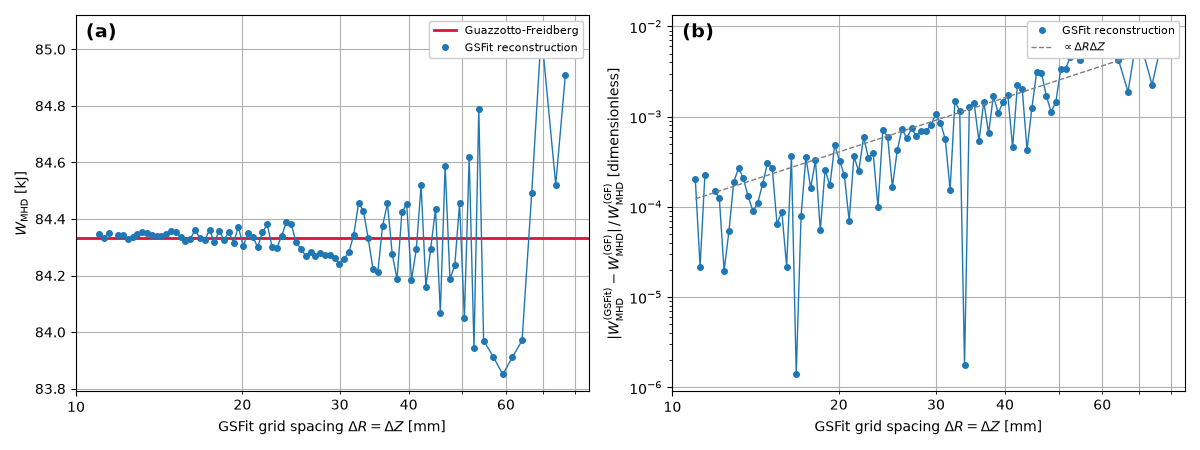

In [ ]:
# --- Grid sensitivity scan, 4 of 4: convergence of the MHD energy, drawn like the beta_pol_3 figure above ---
# The data, the plotter and the figure are kept together in `gsfit_convergence/`, separate from this notebook.
# `gsfit_convergence/gsfit_convergence.py` redraws the figure from `gsfit_convergence.npz` alone (numpy + matplotlib), and writes `gsfit_convergence.pdf` next to itself.
# This cell saves the data, then runs the plotter. The path is relative to this notebook's directory, which is the working directory of its kernel.
from pathlib import Path

gsfit_convergence_path = Path("gsfit_convergence")
np.savez_compressed(
    gsfit_convergence_path / "gsfit_convergence.npz",
    gf_d_r=gf_d_r,  # GF grid radial spacing [metre]
    gf_d_z=gf_d_z,  # GF grid vertical spacing [metre]
    gf_energy_mhd=gf_energy_mhd,  # ground truth [joule]
    scan_converged=scan_converged,  # shape (n_scan,)
    scan_d_grid=scan_d_grid,  # GSFit grid spacing d_r = d_z [metre], shape (n_scan,)
    scan_energy_mhd=scan_energy_mhd,  # [joule], shape (n_scan,)
)
print(f"saved {gsfit_convergence_path / 'gsfit_convergence.npz'}")

%run gsfit_convergence/gsfit_convergence.py